# Viz results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results=pd.read_csv('results.csv')
results.head()

,seed,model_variant,dataset_fraction,resolution,dataset_size,epochs,physical_batch_size,mathematical_batch_size,compile_mode,device,...,recall,f1,flops,params,inference_time_ms,inference_std_ms,fps,gpu_memory_mb,train_loss,val_loss
0,4221376603,yolo11n.pt,0.10,416,718,50,64,64,reduce-overhead,cuda,...,0.467987,0.0,1.397278e+09,2624080.0,9.987998,7.485406,100.120164,1903.431152,0.0,0.0
1,4221376603,yolo11n.pt,0.25,416,1795,50,64,64,reduce-overhead,cuda,...,0.485370,0.0,1.397278e+09,2624080.0,7.915998,1.034635,126.326467,1903.431152,0.0,0.0
2,4221376603,yolo11n.pt,0.50,416,3590,50,64,64,reduce-overhead,cuda,...,0.489960,0.0,1.397278e+09,2624080.0,8.015552,1.535632,124.757478,1903.431152,0.0,0.0
3,4221376603,yolo11n.pt,1.00,416,7180,50,64,64,reduce-overhead,cuda,...,0.499713,0.0,1.397278e+09,2624080.0,11.477027,3.132889,87.130579,1903.430664,0.0,0.0
4,3810243382,yolo11n.pt,0.10,416,718,50,64,64,reduce-overhead,cuda,...,0.468732,0.0,1.397278e+09,2624080.0,10.908661,2.898608,91.670280,1971.572754,0.0,0.0


In [3]:
results.columns

Index(['seed', 'model_variant', 'dataset_fraction', 'resolution',
       'dataset_size', 'epochs', 'physical_batch_size',
       'mathematical_batch_size', 'compile_mode', 'device', 'device_name',
       'timestamp', 'mAP50', 'mAP50_95', 'precision', 'recall', 'f1', 'flops',
       'params', 'inference_time_ms', 'inference_std_ms', 'fps',
       'gpu_memory_mb', 'train_loss', 'val_loss'],
      dtype='str')

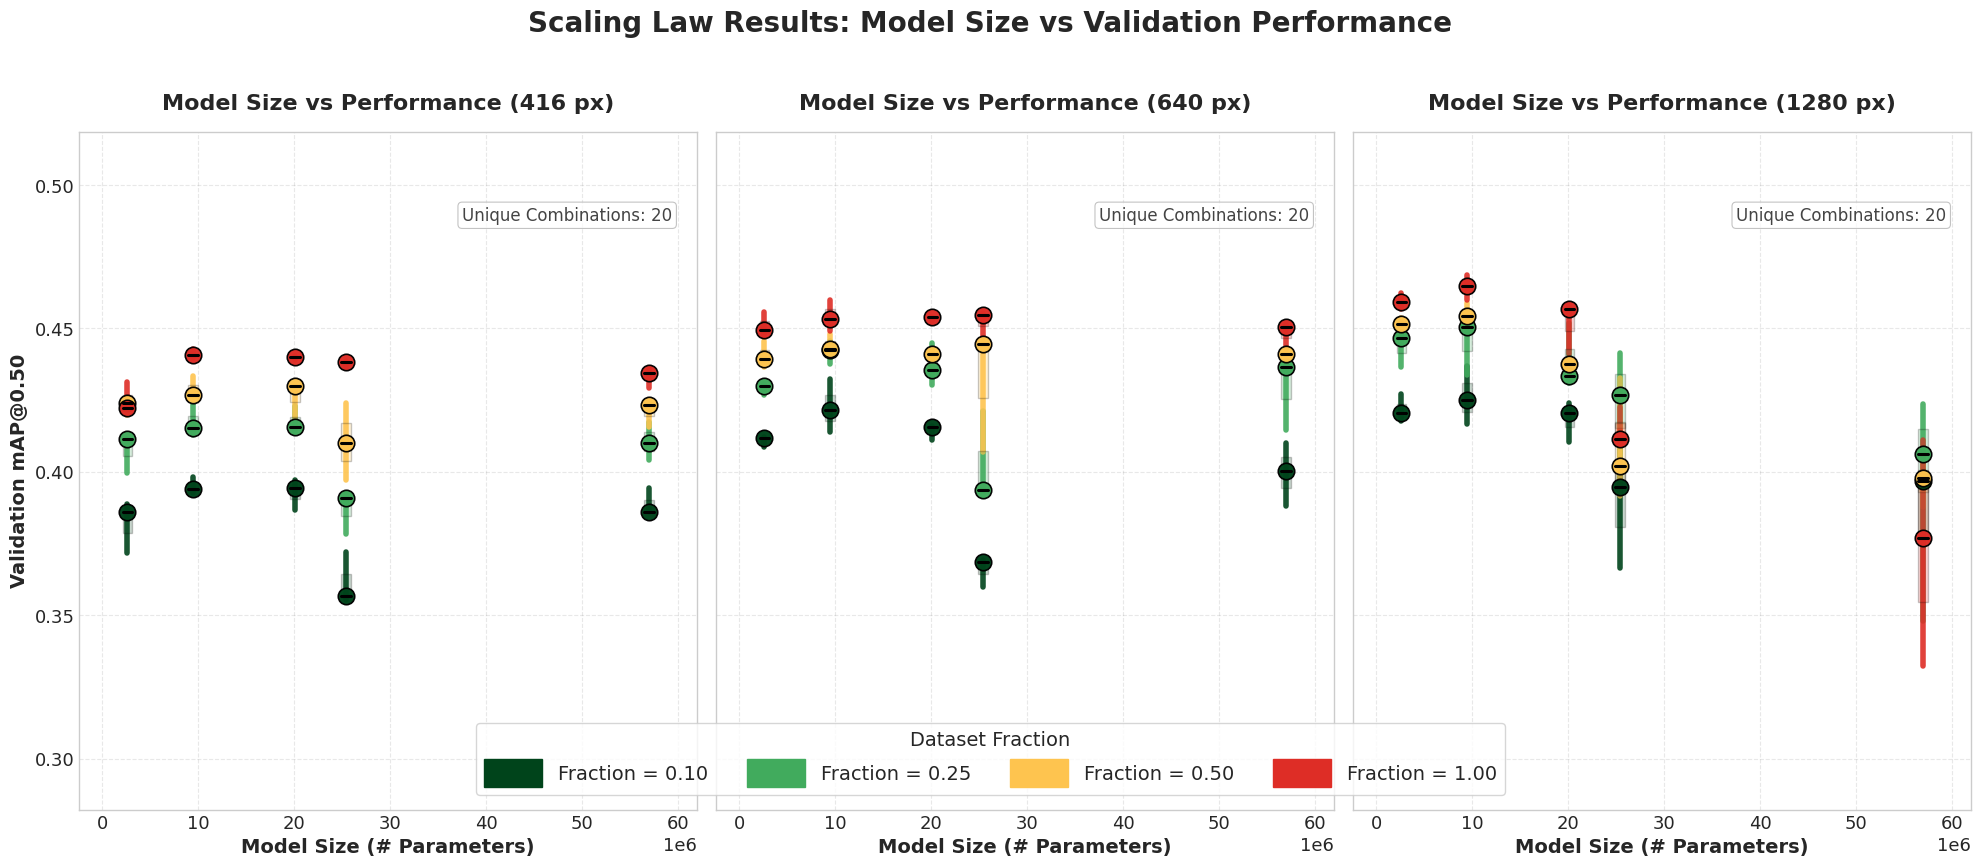

In [4]:
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# More professional style and larger font configuration
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'font.size': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

# Fixed dataset fractions and corresponding colors (professional palette)
frac_levels = [0.10, 0.25, 0.50, 1.00]
frac_to_idx = {v: i for i, v in enumerate(frac_levels)}
custom_colors = ["#00441b", "#41ab5d", "#fec44f", "#de2d26"]  # deep green, light green, gold, deep red
cmap = ListedColormap(custom_colors)

# Increase height for more space for legend below the axes
fig, axes = plt.subplots(1, 3, figsize=(20, 8.5), sharey=True, constrained_layout=True)
resolutions = [416, 640, 1280]
titles = [
    "Model Size vs Performance (416 px)",
    "Model Size vs Performance (640 px)",
    "Model Size vs Performance (1280 px)"
]

# Find duplicated points (same model_variant, dataset_fraction, resolution)
duplicates = results[results.duplicated(subset=['model_variant', 'dataset_fraction', 'resolution'], keep=False)]
duplicate_keys = set(tuple(row) for row in duplicates[['model_variant','dataset_fraction','resolution']].to_numpy())

# Global axis limits for consistency
global_ymin = results['mAP50'].min() - 0.05
global_ymax = results['mAP50'].max() + 0.05
global_xmin = results['params'].min() - 5e6
global_xmax = results['params'].max() + 5e6

for i, (res, ax, title) in enumerate(zip(resolutions, axes, titles)):
    filtered = results[results['resolution'] == res]
    
    # No data for this resolution
    if filtered.empty:
        ax.set_title(title + " [No Data]", fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        continue

    filtered_color_indices = filtered['dataset_fraction'].map(lambda x: frac_to_idx.get(round(float(x), 2), np.nan))
    # Remove undefined fractions (i.e., not in frac_levels)
    mask = ~filtered_color_indices.isna()
    filtered = filtered[mask].reset_index(drop=True)
    filtered_color_indices = filtered_color_indices[mask].reset_index(drop=True)

    plotted_regular = set()
    plotted_dups = set()

    # Plot regular (non-duplicate) points
    for idx in range(len(filtered)):
        row = filtered.iloc[idx]
        key = (row['model_variant'], row['dataset_fraction'], row['resolution'])
        color_idx = filtered_color_indices.iloc[idx]
        color = cmap(int(color_idx))
        if key not in duplicate_keys:
            ax.scatter(row['params'], row['mAP50'],
                       c=[color], s=130, marker='o', 
                       edgecolors='black', linewidths=1.2, zorder=3, alpha=0.84
            )
            plotted_regular.add(key)

    # Plot duplicates with range/boxplot style
    for dup_key in sorted(duplicate_keys):
        mask_dup = (
            (filtered['model_variant'] == dup_key[0]) &
            (filtered['dataset_fraction'] == dup_key[1]) &
            (filtered['resolution'] == dup_key[2])
        )
        filtered_dupes = filtered[mask_dup]
        filtered_dupes_color_idx = filtered_color_indices[mask_dup]
        if not filtered_dupes.empty:
            color_idx = filtered_dupes_color_idx.iloc[0]
            color = cmap(int(color_idx))
            params_val = filtered_dupes['params'].iloc[0]
            mAP50_vals = np.sort(filtered_dupes['mAP50'].values)
            n = len(mAP50_vals)

            if n == 1:
                ax.scatter(params_val, mAP50_vals[0], c=[color], s=130, marker='o', edgecolors='black', linewidths=1.2, zorder=4, alpha=0.9)
            elif n == 2:
                ax.plot([params_val, params_val], [mAP50_vals[0], mAP50_vals[1]],
                        c=color, lw=5.2, solid_capstyle='round', zorder=2, alpha=0.85)
                ax.scatter([params_val, params_val], [mAP50_vals[0], mAP50_vals[1]],
                           c=[color], edgecolors='black', s=130, marker='o', linewidths=1.2, zorder=3, alpha=0.95)
            else:
                q1 = np.percentile(mAP50_vals, 25)
                med = np.percentile(mAP50_vals, 50)
                q3 = np.percentile(mAP50_vals, 75)
                minv = np.min(mAP50_vals)
                maxv = np.max(mAP50_vals)
                box_width = 1e6
                ax.plot([params_val, params_val], [minv, maxv],
                        c=color, lw=4, alpha=0.90, zorder=2)
                box = matplotlib.patches.Rectangle(
                    (params_val - box_width / 2, q1), box_width, q3-q1,
                    linewidth=1.0, edgecolor='black', facecolor=color, alpha=0.22, zorder=3
                )
                ax.add_patch(box)
                ax.plot([params_val - box_width/2, params_val + box_width/2], [med, med], 
                        c='black', lw=2.2, zorder=5)
                ax.scatter(params_val, med, c=[color], edgecolors='black', s=140, marker='o', linewidths=1.2, zorder=4, alpha=0.98)
            plotted_dups.add(dup_key)

    # Axis styles and labels
    ax.set_xlabel('Model Size (# Parameters)', fontweight='bold')
    ax.set_xlim(global_xmin, global_xmax)
    ax.set_ylim(global_ymin, global_ymax)
    #ax.set_xscale('log')
    ax.set_title(title, fontweight='bold', pad=16)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(6,6))
    ax.grid(True, linestyle='--', color='gray', alpha=0.18)
    if i == 0:
        ax.set_ylabel('Validation mAP@0.50', fontweight='bold')

    # Annotate how many unique key points plot, placed in the top right with subtle style
    num_unique_combos = len(plotted_regular | plotted_dups)
    ann_x = global_xmax - (global_xmax - global_xmin) * 0.04
    ann_y = global_ymax - (global_ymax - global_ymin) * 0.11
    ax.text(
        ann_x, ann_y,
        f"Unique Combinations: {num_unique_combos}",
        fontsize=12, color="#444", ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.25", ec="#aaa", fc="#fff", alpha=0.7, linewidth=0.8)
    )

# Shared colorbar setup (as color *legend*)
from matplotlib.cm import ScalarMappable
import warnings; warnings.filterwarnings("ignore", category=UserWarning)

# Custom legend for colors
handles = [
    mpatches.Patch(color=custom_colors[i], label=f"Fraction = {frac_levels[i]:.2f}")
    for i in range(len(frac_levels))
]
legend = fig.legend(
    handles=handles, title="Dataset Fraction",
    loc='lower center', bbox_to_anchor=(0.5, 0.085), ncol=len(frac_levels),
    frameon=True, fontsize=14, title_fontsize=14, handleheight=1.8, handlelength=3,
    # Place legend just below the plot, now that there is more room
)

plt.subplots_adjust(bottom=0.20, top=0.93, left=0.06, right=0.98, wspace=0.21)
fig.suptitle("Scaling Law Results: Model Size vs Validation Performance", fontsize=20, y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# load your CSV
df = pd.read_csv("results.csv")

# keep/clean columns
df = df[['model_variant','dataset_fraction','resolution','dataset_size','params','mAP50']].dropna()
df['dataset_fraction'] = pd.to_numeric(df['dataset_fraction'])
df['resolution'] = pd.to_numeric(df['resolution'])
df['dataset_size'] = pd.to_numeric(df['dataset_size'])
df['params'] = pd.to_numeric(df['params'])
df['mAP50'] = pd.to_numeric(df['mAP50'])

# features
df['log_params'] = np.log10(df['params'])
df['log_dataset_size'] = np.log10(df['dataset_size'])
df['log_resolution'] = np.log10(df['resolution'])

# option A: power-law style (log10 mAP)
eps=1e-6
df['mAP_clip'] = df['mAP50'].clip(eps, 1-eps)
df['log10_mAP'] = np.log10(df['mAP_clip'])

X = df[['log_params','log_dataset_size','log_resolution']]
X = sm.add_constant(X)
y = df['log10_mAP']

model = sm.OLS(y, X).fit(cov_type='HC3')  # robust SE
print(model.summary())

# option B: logit(mAP)
df['logit_mAP'] = np.log(df['mAP_clip'] / (1-df['mAP_clip']))
y2 = df['logit_mAP']
model2 = sm.OLS(y2, X).fit(cov_type='HC3')
print(model2.summary())

# Estimate per-resolution (iso-resolution analysis)
for res in sorted(df['resolution'].unique()):
    sub = df[df['resolution']==res]
    if len(sub) >= 4:
        Xs = sm.add_constant(sub[['log_params','log_dataset_size']])
        ys = np.log(sub['mAP50'].clip(eps,1-eps) / (1-sub['mAP50'].clip(eps,1-eps)))
        m = sm.OLS(ys, Xs).fit(cov_type='HC3')
        print(f"Resolution {res}:")
        print(m.summary())


                            OLS Regression Results                            
Dep. Variable:              log10_mAP   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     59.08
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.80e-26
Time:                        01:32:40   Log-Likelihood:                 443.39
No. Observations:                 180   AIC:                            -878.8
Df Residuals:                     176   BIC:                            -866.0
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.4566      0.054  

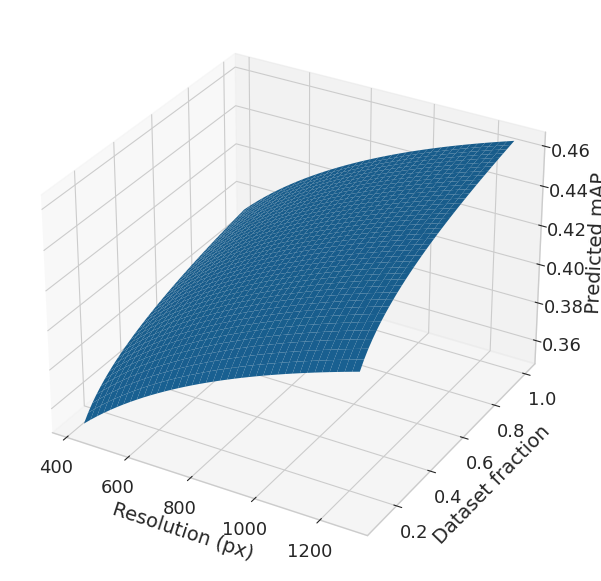

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Coefficients from logit_mAP regression
const = -1.5220
a = -0.0838       # log_params
b = 0.1816        # log_dataset
c = 0.6060        # log_resolution

# Fix model size (log_params). Typical YOLO11 models range 2M–40M params => log10 ≈ 6 ± 1
log_params_fixed = 6.0

# Grid for resolution (px) and dataset size (fraction)
resolutions = np.linspace(416, 1280, 40)
dataset_fracs = np.linspace(0.1, 1.0, 40)

R, D = np.meshgrid(resolutions, dataset_fracs)

log_res = np.log10(R)
log_ds = np.log10(D)

# Logit form
logit = const + a*log_params_fixed + b*log_ds + c*log_res
mAP = 1 / (1 + np.exp(-logit))  # inverse logit

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(R, D, mAP)

ax.set_xlabel('Resolution (px)')
ax.set_ylabel('Dataset fraction')
ax.set_zlabel('Predicted mAP')

plt.tight_layout()
plt.show()


Unique model sizes (params): [np.float64(2624080.0), np.float64(9458752.0), np.float64(20114688.0), np.float64(25372160.0), np.float64(56874931.0), np.float64(56966176.0)]
Unique dataset fractions: [np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0)]
Unique resolutions: [np.int64(416), np.int64(640), np.int64(1280)]


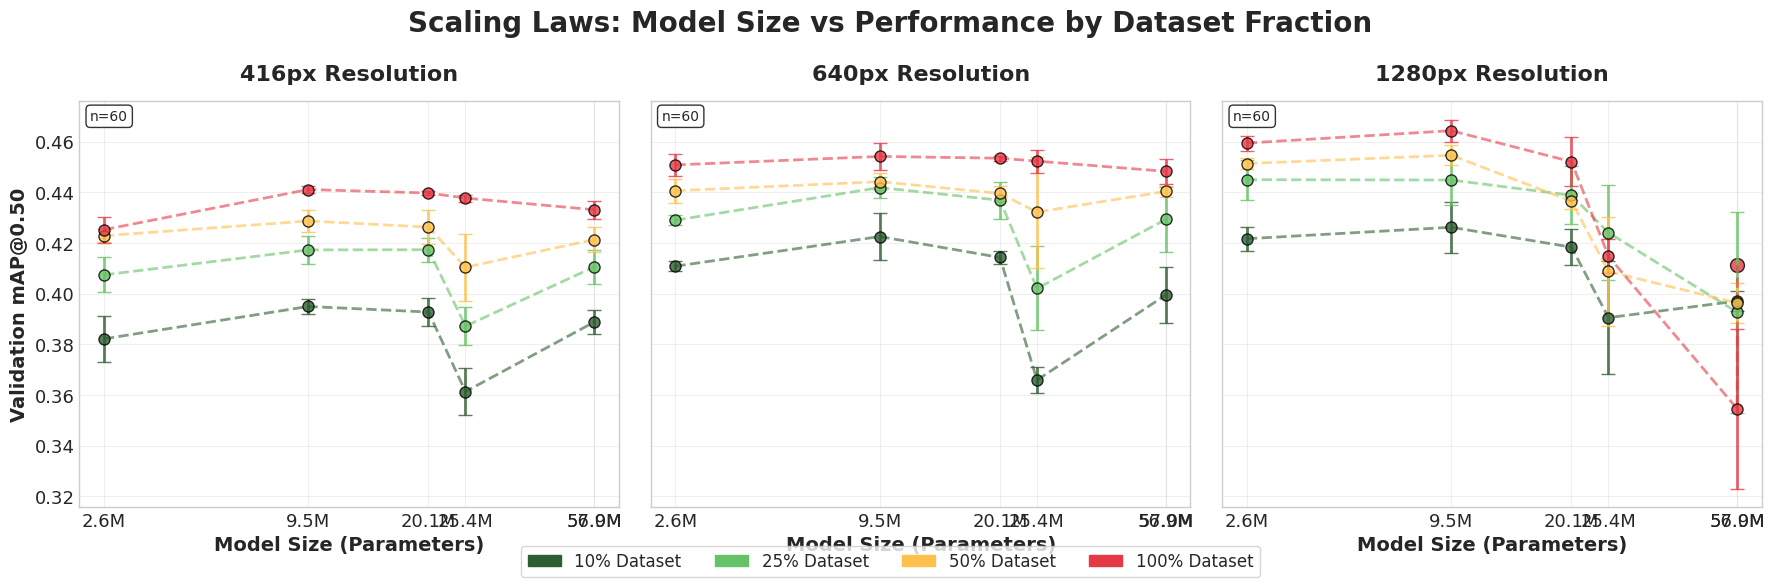

Plot saved successfully!
Data shape: (180, 25)
Unique model sizes: 6 sizes
Model size range: ['2.6M', '9.5M', '20.1M', '25.4M', '56.9M', '57.0M']
Dataset fractions: 4 fractions
Fraction range: ['10%', '25%', '50%', '100%']
Resolutions: [np.int64(416), np.int64(640), np.int64(1280)]
Performance range: 0.332 - 0.469


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'font.size': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.titlesize': 18,
    'font.family': 'DejaVu Sans'
})

# Load actual data from CSV

results = pd.read_csv('results.csv')


# Get unique values from actual data
unique_model_sizes = sorted(results['params'].unique())
unique_fractions = sorted(results['dataset_fraction'].unique()) 
unique_resolutions = sorted(results['resolution'].unique())

print(f"Unique model sizes (params): {unique_model_sizes}")
print(f"Unique dataset fractions: {unique_fractions}")
print(f"Unique resolutions: {unique_resolutions}")

# Create readable labels for model sizes
def format_model_size(params):
    if params >= 1e9:
        return f"{params/1e9:.1f}B"
    elif params >= 1e6:
        return f"{params/1e6:.1f}M"
    elif params >= 1e3:
        return f"{params/1e3:.1f}K"
    else:
        return f"{int(params)}"

model_size_labels = [format_model_size(size) for size in unique_model_sizes]

# Create labels for dataset fractions
fraction_labels = [f"{int(frac*100)}%" for frac in unique_fractions]

# Use actual data values
dataset_fractions = unique_fractions
model_sizes = unique_model_sizes
resolutions = unique_resolutions

# Color setup - adjust number of colors based on actual fractions
custom_colors = ["#2d5d31", "#66c266", "#ffc14d", "#e63946", "#8e44ad", "#e67e22"]  # Extended palette
if len(unique_fractions) <= len(custom_colors):
    colors_to_use = custom_colors[:len(unique_fractions)]
else:
    # Generate more colors if needed
    from matplotlib.cm import tab10
    colors_to_use = [tab10(i) for i in range(len(unique_fractions))]

cmap = ListedColormap(colors_to_use)
frac_to_idx = {frac: i for i, frac in enumerate(dataset_fractions)}

# Determine subplot configuration based on available resolutions
n_resolutions = len(resolutions)
if n_resolutions == 1:
    fig, axes = plt.subplots(1, 1, figsize=(8, 6))
    axes = [axes]
elif n_resolutions == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
else:
    fig, axes = plt.subplots(1, min(3, n_resolutions), figsize=(6*min(3, n_resolutions), 6), sharey=True)
    if n_resolutions == 1:
        axes = [axes]

fig.suptitle("Scaling Laws: Model Size vs Performance by Dataset Fraction", 
             fontsize=20, fontweight='bold', y=0.98)

# Plot for each resolution
for ax_idx, (ax, res) in enumerate(zip(axes, resolutions)):
    filtered_data = results[results['resolution'] == res]
    
    if filtered_data.empty:
        ax.set_title(f'{res}px Resolution [No Data]', fontweight='bold', pad=15)
        ax.text(0.5, 0.5, 'No data available', transform=ax.transAxes, 
                ha='center', va='center', fontsize=14, style='italic')
        continue
    
    # Plot points for each dataset fraction
    for frac in dataset_fractions:
        frac_data = filtered_data[filtered_data['dataset_fraction'] == frac]
        
        if frac_data.empty:
            continue
            
        color_idx = frac_to_idx[frac]
        color = colors_to_use[color_idx]
        
        # Handle potential duplicates by plotting mean with error bars if multiple runs exist
        grouped = frac_data.groupby('params')['mAP50'].agg(['mean', 'std', 'count']).reset_index()
        
        for _, row in grouped.iterrows():
            if row['count'] == 1:
                # Single measurement
                ax.scatter(row['params'], row['mean'], c=color, s=100, alpha=0.8, 
                          edgecolors='black', linewidth=1,
                          label=f'{fraction_labels[color_idx]} Data' if ax_idx == 0 else "")
            else:
                # Multiple measurements - show mean with error bars
                ax.errorbar(row['params'], row['mean'], yerr=row['std'], 
                           fmt='o', color=color, markersize=8, alpha=0.8,
                           ecolor=color, elinewidth=2, capsize=5, capthick=2,
                           markeredgecolor='black', markeredgewidth=1,
                           label=f'{fraction_labels[color_idx]} Data' if ax_idx == 0 else "")
        
        # Add trend line for each fraction if we have multiple points
        if len(grouped) > 1:
            ax.plot(grouped['params'], grouped['mean'], color=color, alpha=0.6, 
                   linewidth=2, linestyle='--')
    
    # Formatting
    ax.set_xlabel('Model Size (Parameters)', fontweight='bold')
    ax.set_title(f'{res}px Resolution', fontweight='bold', pad=15)
    
    # Use log scale if model sizes span more than one order of magnitude
    size_range = max(unique_model_sizes) / min(unique_model_sizes)
    if size_range > 10:
        ax.set_xscale('log')
        ax.set_xticks(unique_model_sizes)
        ax.set_xticklabels(model_size_labels)
    else:
        # Use linear scale with formatted labels
        ax.set_xticks(unique_model_sizes)
        ax.set_xticklabels(model_size_labels, rotation=45)
    
    ax.grid(True, alpha=0.3)
    
    if ax_idx == 0:
        ax.set_ylabel('Validation mAP@0.50', fontweight='bold')
    
    # Add data point count annotation
    total_points = len(filtered_data)
    ax.text(0.02, 0.98, f'n={total_points}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Add legend only if we have data
if not results.empty:
    handles = [mpatches.Patch(color=colors_to_use[i], label=f'{fraction_labels[i]} Dataset')
               for i in range(len(dataset_fractions))]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.02),
               ncol=min(len(dataset_fractions), 4), frameon=True, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

print("Plot saved successfully!")
print(f"Data shape: {results.shape}")
print(f"Unique model sizes: {len(unique_model_sizes)} sizes")
print(f"Model size range: {model_size_labels}")
print(f"Dataset fractions: {len(unique_fractions)} fractions")
print(f"Fraction range: {fraction_labels}")
print(f"Resolutions: {resolutions}")
print(f"Performance range: {results['mAP50'].min():.3f} - {results['mAP50'].max():.3f}")

In [8]:
res=1280


# res 640
#yolo11m.pt @0.25 mAP50: 0.5526750319954635
#yolo11m.pt @0.5  mAP50: 0.5526750319954635
#mAP50 for yolo11m.pt 0.25 and 0.5 are EQUAL.

# res 416
#yolo11m.pt @0.1 mAP50: 0.5198536195728702
#yolo11m.pt @0.25 mAP50: 0.5198536195728702
#yolo11m.pt @0.5 mAP50: 0.5198536195728702
# mAP50 for yolo11m.pt 0.1, 0.25, and 0.5 are ALL EQUAL.


subset = results[(results['resolution']==res)].drop_duplicates(subset=['model_variant', 'dataset_fraction', 'resolution'])
subset = subset.sort_values(by=['model_variant', 'dataset_fraction'])
subset

,seed,model_variant,dataset_fraction,resolution,dataset_size,epochs,physical_batch_size,mathematical_batch_size,compile_mode,device,...,recall,f1,flops,params,inference_time_ms,inference_std_ms,fps,gpu_memory_mb,train_loss,val_loss
155,4221376603,yolo11l.pt,0.10,1280,718,50,8,64,default,cuda,...,0.506024,0.0,1.752270e+11,25372160.0,76.352053,0.423419,13.097225,10589.235840,0.0,0.0
156,4221376603,yolo11l.pt,0.25,1280,1795,50,8,64,default,cuda,...,0.538726,0.0,1.752270e+11,25372160.0,76.139164,0.220166,13.133845,10589.235840,0.0,0.0
157,4221376603,yolo11l.pt,0.50,1280,3590,50,8,64,default,cuda,...,0.483075,0.0,1.752270e+11,25372160.0,76.032910,0.306151,13.152199,13831.236328,0.0,0.0
158,4221376603,yolo11l.pt,1.00,1280,7180,50,8,64,default,cuda,...,0.515447,0.0,1.752270e+11,25372160.0,76.101437,0.326814,13.140356,13832.720703,0.0,0.0
113,4221376603,yolo11m.pt,0.10,1280,718,50,16,64,default,cuda,...,0.537579,0.0,1.370568e+11,20114688.0,35.093021,0.230565,28.495694,14573.817383,0.0,0.0
114,4221376603,yolo11m.pt,0.25,1280,1795,50,16,64,default,cuda,...,0.558233,0.0,1.370568e+11,20114688.0,34.146309,0.169643,29.285742,14569.754883,0.0,0.0
116,3810243382,yolo11m.pt,0.50,1280,3590,50,16,64,default,cuda,...,0.547906,0.0,1.370568e+11,20114688.0,35.242023,0.253080,28.375215,14569.754883,0.0,0.0
122,4221376603,yolo11m.pt,1.00,1280,7180,50,8,64,default,cuda,...,0.543189,0.0,1.370568e+11,20114688.0,53.713522,0.293263,18.617286,10265.282227,0.0,0.0
24,4221376603,yolo11n.pt,0.10,1280,718,50,32,64,False,cuda,...,0.537579,0.0,1.322867e+10,2624080.0,8.523002,1.032824,117.329556,12592.495117,0.0,0.0
25,4221376603,yolo11n.pt,0.25,1280,1795,50,32,64,False,cuda,...,0.549123,0.0,1.322867e+10,2624080.0,8.724532,1.140814,114.619327,12811.889648,0.0,0.0


In [9]:
# Check mAP50 for yolo11m.pt at dataset fractions 0.1, 0.25, and 0.5 at given resolution
fractions = [0.1, 0.25, 0.5]
mask = (subset['model_variant'] == 'yolo11m.pt') & (subset['dataset_fraction'].isin(fractions))
yolo11m_pts = subset[mask][['dataset_fraction', 'mAP50']].set_index('dataset_fraction').sort_index()

found_fracs = [frac for frac in fractions if frac in yolo11m_pts.index]

for frac in found_fracs:
    print(f"yolo11m.pt @{frac} mAP50: {yolo11m_pts.loc[frac, 'mAP50']}")

if all(frac in yolo11m_pts.index for frac in fractions):
    map_01 = yolo11m_pts.loc[0.1, 'mAP50']
    map_025 = yolo11m_pts.loc[0.25, 'mAP50']
    map_05 = yolo11m_pts.loc[0.5, 'mAP50']
    if map_01 == map_025 == map_05:
        print("mAP50 for yolo11m.pt 0.1, 0.25, and 0.5 are ALL EQUAL.")
    elif map_01 == map_025 and map_025 != map_05:
        print("mAP50 for yolo11m.pt 0.1 and 0.25 are EQUAL; 0.5 is DIFFERENT.")
    elif map_025 == map_05 and map_01 != map_025:
        print("mAP50 for yolo11m.pt 0.25 and 0.5 are EQUAL; 0.1 is DIFFERENT.")
    else:
        print("mAP50 for yolo11m.pt 0.1, 0.25, and 0.5 are ALL DIFFERENT or pairwise different.")
else:
    print(f"Could not find all dataset fractions {fractions} for yolo11m.pt in subset.")


yolo11m.pt @0.1 mAP50: 0.4103720158693335
yolo11m.pt @0.25 mAP50: 0.4519865883505505
yolo11m.pt @0.5 mAP50: 0.437492772901709
mAP50 for yolo11m.pt 0.1, 0.25, and 0.5 are ALL DIFFERENT or pairwise different.
